In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

print(df.shape)
df.head()

(780, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [2]:
sns.set_theme(style="whitegrid")

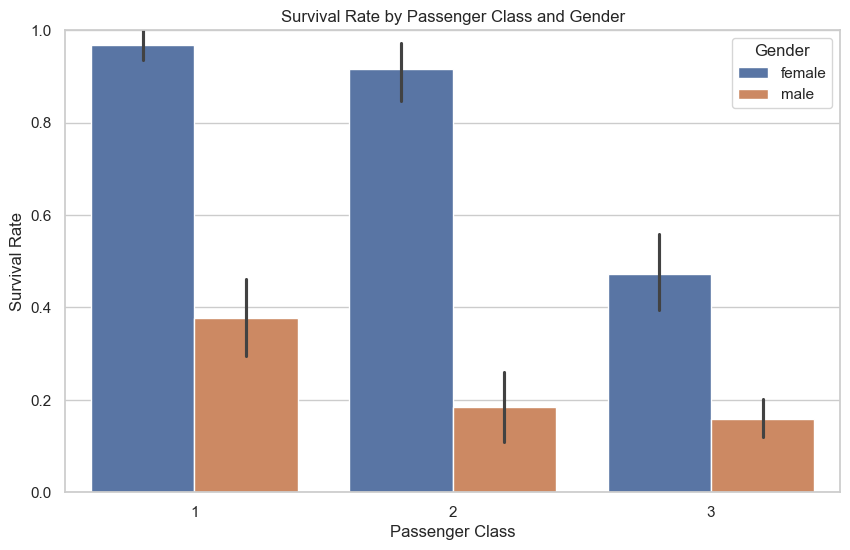

In [3]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.legend(title="Gender")

plt.show()

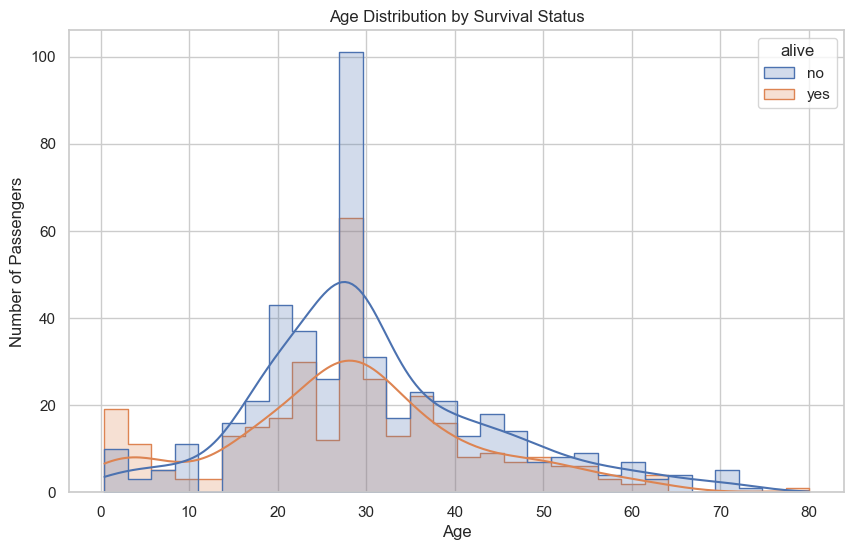

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    hue="alive",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

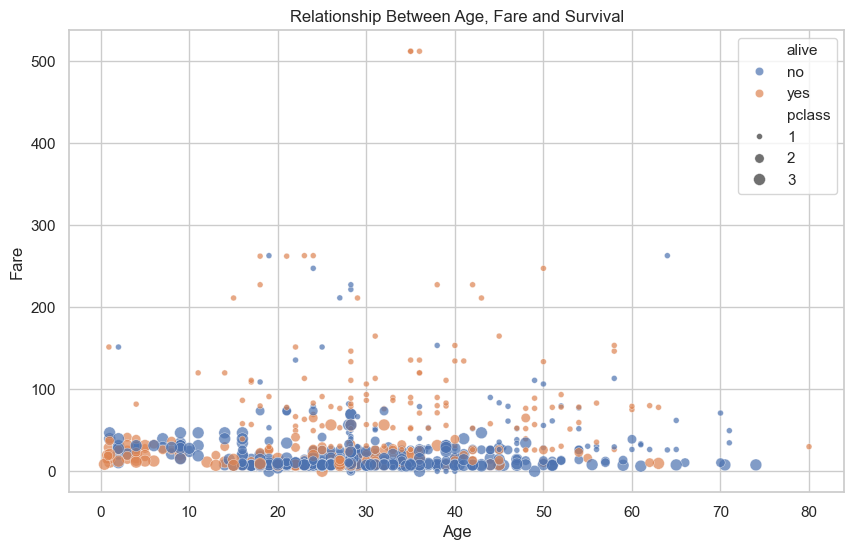

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="alive",
    size="pclass",
    alpha=0.7
)

plt.title("Relationship Between Age, Fare and Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [6]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

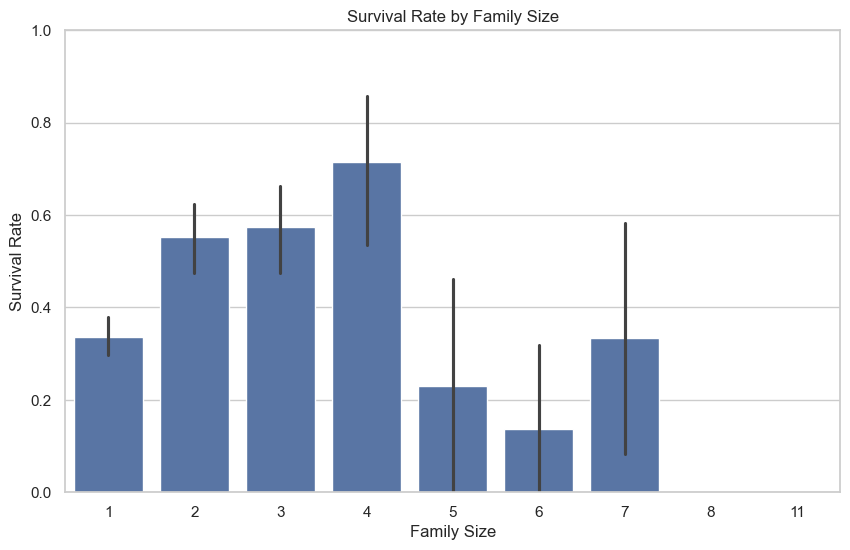

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="family_size",
    y="survived"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

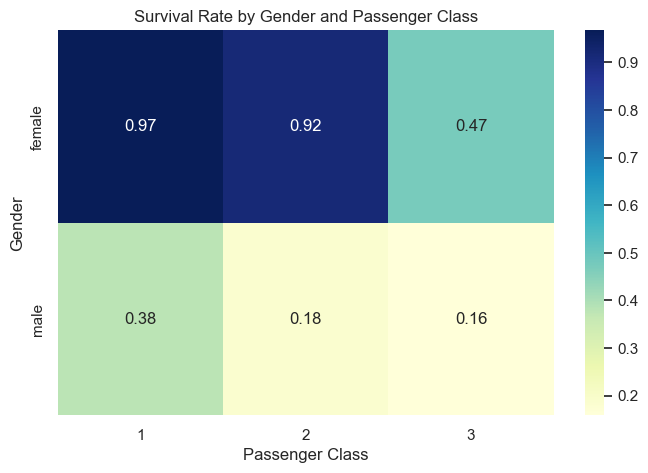

In [8]:
survival_heatmap = pd.pivot_table(
    df,
    values="survived",
    index="sex",
    columns="pclass",
    aggfunc="mean"
) 
plt.figure(figsize=(8, 5))

sns.heatmap(
    survival_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Gender")

plt.show()

In [9]:
print("WEEK 2 KEY RESULTS")
print("=" * 50)

print("\n1. Survival Rate by Gender and Class:")
print(
    df.groupby(["sex", "pclass"], observed=True)["survived"]
      .mean()
      .mul(100)
      .round(2)
)

print("\n2. Survival Rate by Family Size:")
print(
    df.groupby("family_size")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

print("\n3. Average Fare by Survival:")
print(
    df.groupby("alive", observed=True)["fare"]
      .mean()
      .round(2)
)

print("\n4. Average Age by Survival:")
print(
    df.groupby("alive", observed=True)["age"]
      .mean()
      .round(2)
)

WEEK 2 KEY RESULTS

1. Survival Rate by Gender and Class:
sex     pclass
female  1         96.77
        2         91.67
        3         47.24
male    1         37.82
        2         18.48
        3         15.88
Name: survived, dtype: float64

2. Survival Rate by Family Size:
family_size
1     33.71
2     55.19
3     57.43
4     71.43
5     23.08
6     13.64
7     33.33
8      0.00
11     0.00
Name: survived, dtype: float64

3. Average Fare by Survival:
alive
no     24.03
yes    50.19
Name: fare, dtype: float64

4. Average Age by Survival:
alive
no     30.50
yes    28.33
Name: age, dtype: float64
